# Week 03: Sampling & Aliasing

## Overview
In this week’s lecture, we will delve deeply into the concepts of **sampling**, **aliasing**, and the **Nyquist theorem**, which are the bedrock of digital signal processing (DSP). The core learning objectives for this week are as follows:

- Understand the **Nyquist rate** and the **sampling theorem**.
- Visualize and demonstrate **aliasing** with real-world examples.
- Learn how **sampling** can be applied to signals to convert them into discrete forms.
- Explore methods to **reconstruct** the original signal from its samples.
- Analyze real-world scenarios where improper sampling leads to aliasing.

This week’s lecture will involve interactive examples and visualizations, so please feel free to try them yourself and experiment with different parameters.

## 1. The Nyquist Rate and Sampling Theorem

The **Nyquist rate** is defined as twice the maximum frequency component present in a continuous-time signal. It is the minimum sampling rate needed to capture all the information in the signal without losing any data.

### Sampling Theorem
The **Sampling Theorem**, also known as the **Nyquist-Shannon theorem**, states that in order to reconstruct a signal perfectly from its samples, the signal must be sampled at a frequency greater than or equal to twice the highest frequency component of the signal.

Mathematically:
- If $ f_{\text{max}} $ is the maximum frequency in the signal, the minimum sampling frequency $ f_s $ must satisfy:

$$ f_s \geq 2 \times f_{\text{max}} $$

If the signal is sampled at less than this rate (i.e., **under-sampled**), the signal will exhibit **aliasing**, which leads to a loss of information and distortion.

### Practical Implication
If a signal has a highest frequency component of 5 kHz, the Nyquist rate is 10 kHz. This means the signal must be sampled at 10 kHz or higher to ensure accurate digital representation.

---


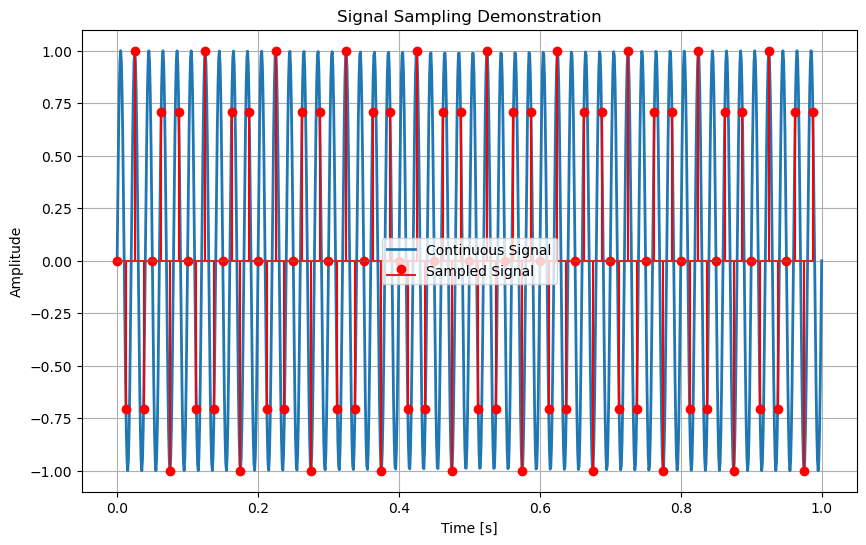

In [4]:
# Let's define a high-frequency signal to demonstrate sampling and aliasing
import numpy as np
import matplotlib.pyplot as plt

f_max = 50  # Maximum frequency (Hz)
f_sample = 80  # Sampling frequency (Hz) - example where sampling < Nyquist rate
t_cont = np.linspace(0, 1, 1000)  # Continuous time
signal_cont = np.sin(2 * np.pi * f_max * t_cont)  # Continuous-time sine wave

# Sample the signal at a lower rate
t_sampled = np.arange(0, 1, 1/f_sample)
signal_sampled = np.sin(2 * np.pi * f_max * t_sampled)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t_cont, signal_cont, label='Continuous Signal', linewidth=2)
plt.stem(t_sampled, signal_sampled, 'r', label='Sampled Signal')
plt.title('Signal Sampling Demonstration')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### Observations

In the plot above, the **continuous signal** is represented by the smooth curve, while the **sampled signal** is represented by the red stems. You can see that the sampled signal is under-sampled compared to the continuous signal, and this can result in aliasing when the sampling rate is not high enough.

When the signal is sampled at a rate below the Nyquist rate, we observe aliasing, where higher-frequency components are incorrectly mapped to lower frequencies. This is a key reason why the Nyquist rate is critical to understanding proper sampling.

---


## 2. Aliasing - Why It Happens

### What is Aliasing?
Aliasing occurs when a signal is sampled at a frequency less than twice its maximum frequency. As a result, high-frequency components of the signal are misrepresented as low-frequency components in the sampled signal. This causes distortion in the reconstructed signal.

### Demonstrating Aliasing
We will now demonstrate aliasing by using a sine wave signal sampled at various frequencies and comparing the results. We'll sample at both **sub-Nyquist** and **Nyquist-compliant** rates to visualize the effects of aliasing.

---


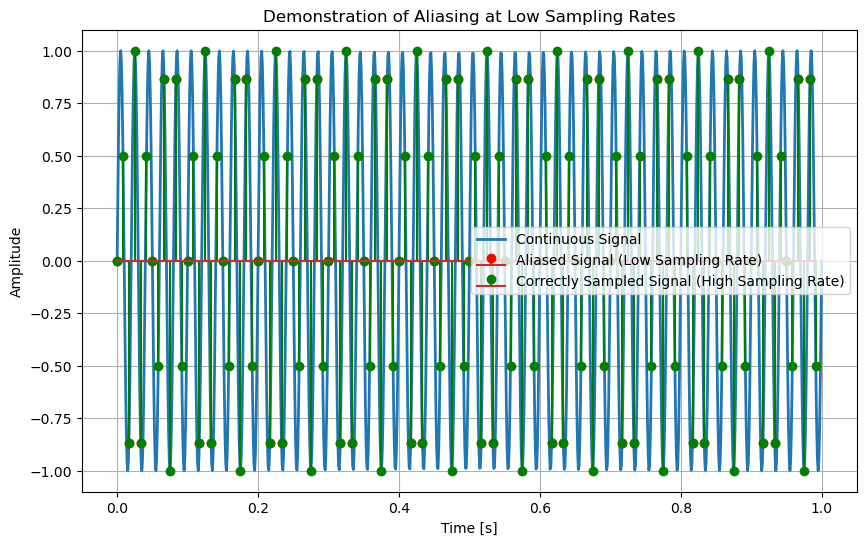

In [5]:
# Demonstrating aliasing with different sampling frequencies
f_max = 50  # Maximum frequency (Hz)
f_sampling_low = 60  # Below Nyquist rate
f_sampling_high = 120  # Above Nyquist rate

t_cont = np.linspace(0, 1, 1000)  # Continuous time
signal_cont = np.sin(2 * np.pi * f_max * t_cont)  # Continuous signal

t_sampled_low = np.arange(0, 1, 1/f_sampling_low)
signal_sampled_low = np.sin(2 * np.pi * f_max * t_sampled_low)

t_sampled_high = np.arange(0, 1, 1/f_sampling_high)
signal_sampled_high = np.sin(2 * np.pi * f_max * t_sampled_high)

# Plot
plt.figure(figsize=(10, 6))

# Continuous signal
plt.plot(t_cont, signal_cont, label='Continuous Signal', linewidth=2)

# Aliased signal (Low Sampling Rate)
plt.stem(t_sampled_low, signal_sampled_low, 'r', label='Aliased Signal (Low Sampling Rate)')

# Correctly Sampled Signal (High Sampling Rate)
plt.stem(t_sampled_high, signal_sampled_high, 'g', label='Correctly Sampled Signal (High Sampling Rate)')

plt.title('Demonstration of Aliasing at Low Sampling Rates')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### Aliasing Observations

In the plot above, we observe:
- **Aliased signal** (red stems): When the signal is sampled at a rate lower than the Nyquist rate (60 Hz for a 50 Hz signal), aliasing occurs. The high-frequency components fold over into lower frequencies, causing distortion in the sampled signal.
- **Correctly sampled signal** (green stems): When the signal is sampled at a rate above the Nyquist rate (120 Hz for a 50 Hz signal), there is no aliasing, and the sampled signal accurately represents the continuous signal.

This visualization highlights the importance of choosing an appropriate sampling rate to avoid aliasing.

---


## 3. Signal Reconstruction from Samples

### Reconstructing the Signal
Once a signal is sampled correctly, we can reconstruct the continuous-time signal from its samples by using **interpolation** or a **reconstruction filter**. The goal is to smooth the samples to approximate the original signal without introducing high-frequency components that were not part of the original signal.

The most common method for reconstructing a signal is by applying a **low-pass filter** to remove the high-frequency components that cause aliasing.

---


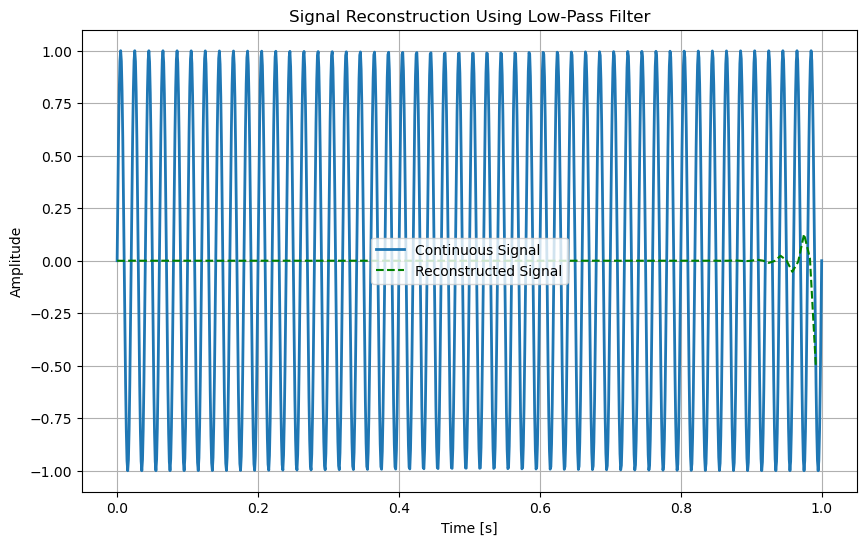

In [6]:
# Reconstructing signal from samples using a low-pass filter
from scipy.signal import butter, filtfilt

def low_pass_filter(data, cutoff_freq, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

cutoff = 30  # Cutoff frequency for low-pass filter (Hz)
sampling_rate = 120  # Sampling frequency (Hz)
reconstructed_signal = low_pass_filter(signal_sampled_high, cutoff, sampling_rate)

# Plot the reconstructed signal
plt.figure(figsize=(10, 6))
plt.plot(t_cont, signal_cont, label='Continuous Signal', linewidth=2)
plt.plot(t_sampled_high, reconstructed_signal, 'g', label='Reconstructed Signal', linestyle='dashed')
plt.title('Signal Reconstruction Using Low-Pass Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### Signal Reconstruction Observations

In the plot above, the **green dashed line** represents the **reconstructed signal** after applying a low-pass filter. It closely matches the original continuous signal, showing how proper signal reconstruction can restore the original signal from its samples.

The low-pass filter effectively removes any high-frequency noise or aliasing components, preserving the key characteristics of the signal.

---
### Conclusion
This week, we explored the fundamental concepts of **sampling**, **aliasing**, and **signal reconstruction**. We saw how under-sampling can lead to aliasing and how proper reconstruction techniques can recover the original signal. These principles are critical when working with real-world signals in digital signal processing.

Next week, we will dive into advanced signal processing techniques such as **Fourier transforms**, **wavelets**, and their applications in real-world problems.